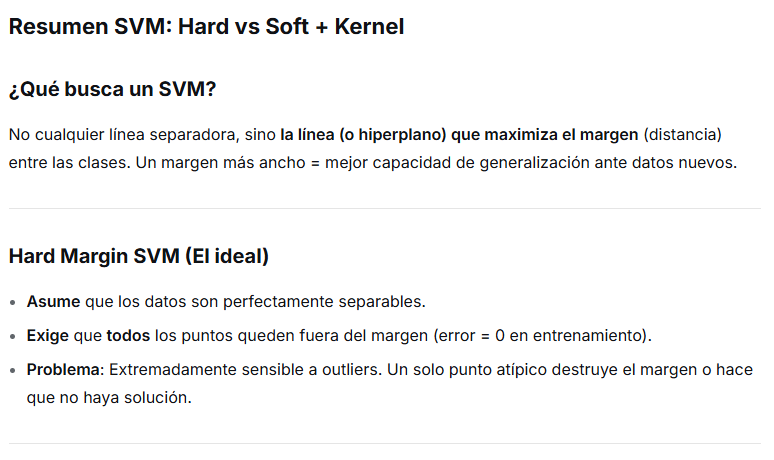
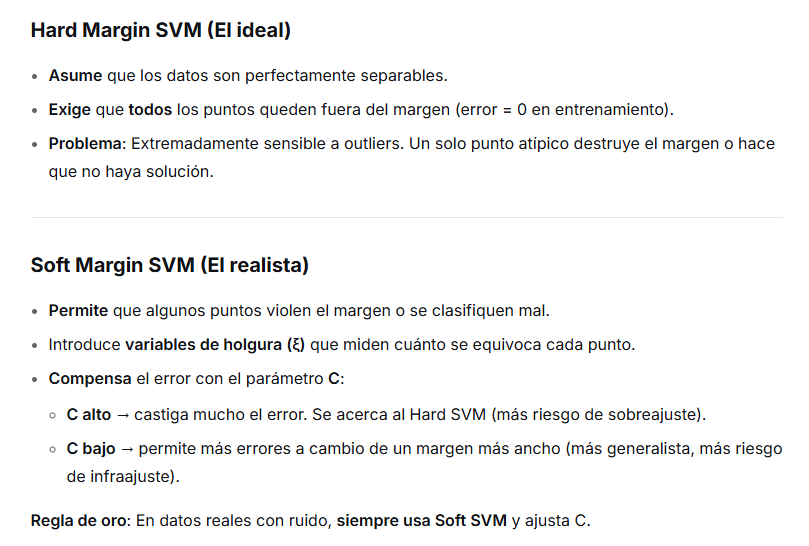
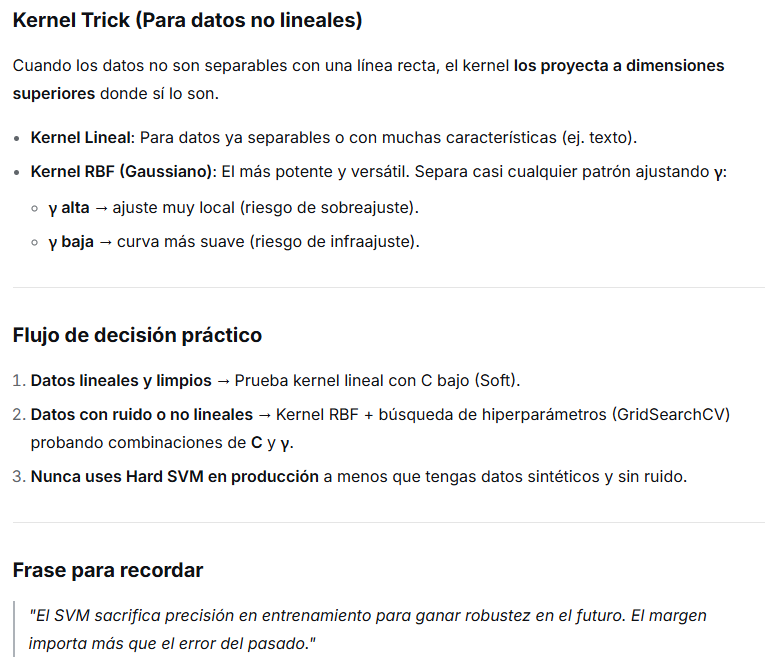

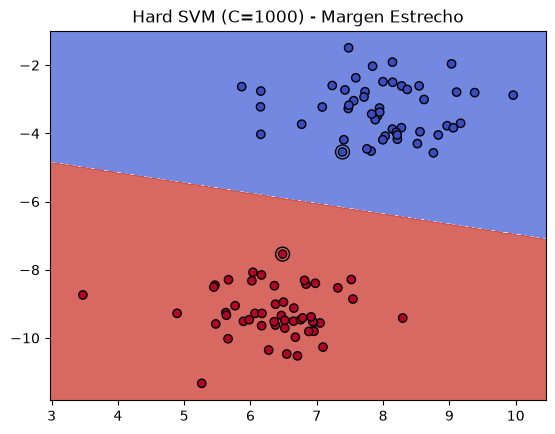

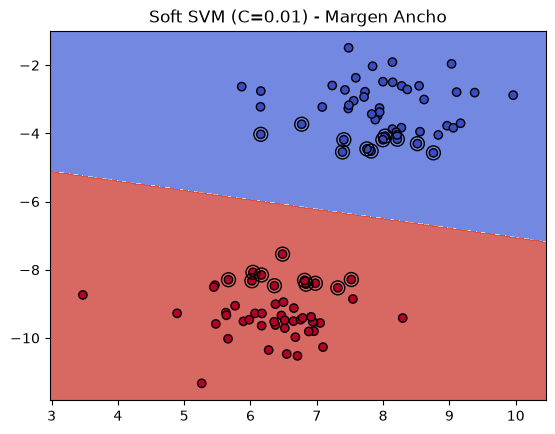

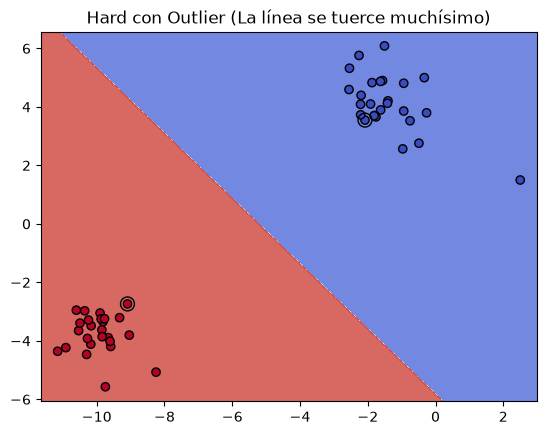

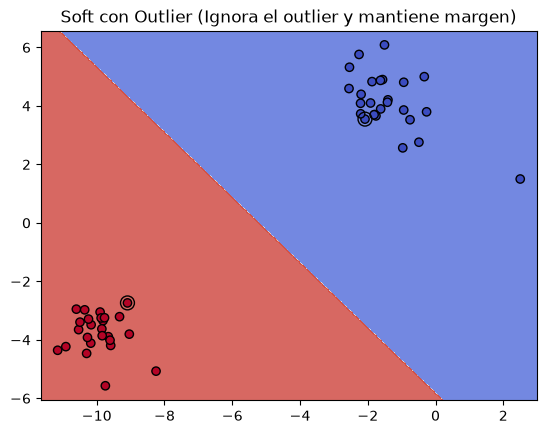

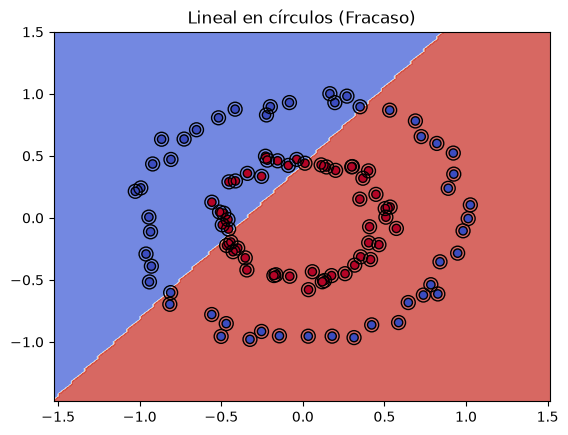

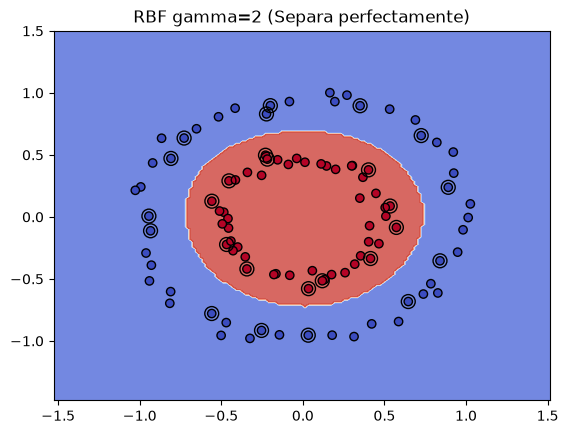

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Función para pintar bonito
def plot_decision_boundary(clf, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    # Resaltar los vectores soporte (los puntos que definen el margen)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], 
                s=100, linewidth=1, facecolors='none', edgecolors='k')
    plt.title(title)
    plt.show()

# --- CASO 1: DATOS SEPARABLES (Hard vs Soft) ---
X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=0.8)

# Hard SVM (C muy alto)
clf_hard = svm.SVC(kernel='linear', C=1000).fit(X, y)
# Soft SVM (C bajo)
clf_soft = svm.SVC(kernel='linear', C=0.01).fit(X, y)

plot_decision_boundary(clf_hard, X, y, "Hard SVM (C=1000) - Margen Estrecho")
plot_decision_boundary(clf_soft, X, y, "Soft SVM (C=0.01) - Margen Ancho")
# Observa: El Hard tiene menos vectores soporte (círculos con borde) y el margen es más fino.
# El Soft tiene más vectores soporte y margen más ancho, aunque sacrifica precisión en entrenamiento.

# --- CASO 2: DATOS CON OUTLIER (El poder del Soft) ---
# Añadimos un outlier malicioso
X_out, y_out = make_blobs(n_samples=50, centers=2, random_state=1, cluster_std=0.8)
X_out = np.vstack([X_out, [[2.5, 1.5]]]) # Outlier
y_out = np.append(y_out, [0]) 

clf_hard_out = svm.SVC(kernel='linear', C=1000).fit(X_out, y_out)
clf_soft_out = svm.SVC(kernel='linear', C=0.1).fit(X_out, y_out)

plot_decision_boundary(clf_hard_out, X_out, y_out, "Hard con Outlier (La línea se tuerce muchísimo)")
plot_decision_boundary(clf_soft_out, X_out, y_out, "Soft con Outlier (Ignora el outlier y mantiene margen)")

# --- CASO 3: DATOS NO LINEALES (El poder del Kernel RBF) ---
X_circ, y_circ = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=1)

# Lineal (Fracasa)
clf_linear = svm.SVC(kernel='linear', C=1).fit(X_circ, y_circ)
# RBF (Éxito)
clf_rbf = svm.SVC(kernel='rbf', gamma=2, C=1).fit(X_circ, y_circ)

plot_decision_boundary(clf_linear, X_circ, y_circ, "Lineal en círculos (Fracaso)")
plot_decision_boundary(clf_rbf, X_circ, y_circ, "RBF gamma=2 (Separa perfectamente)")
